# Model Evaluation Results Viewer

This notebook loads the results of model evaluation runs from `tmp/outputs/model_check` and visualizes the key performance metrics.

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [10]:
import sys
from pathlib import Path  # noqa: F811

# Resolve root directory path
current_dir = Path.cwd()
if current_dir.name == "model_check":
    root_dir = current_dir.parents[1]
else:
    root_dir = current_dir

if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from tools.model_check.run_all_models import RESULTS_DIR  # noqa: E402

csv_files = list(RESULTS_DIR.glob("model_comparison_*.csv"))

dfs = []
for csv_file in csv_files:
    # Extract run name from model_comparison_{run_name}.csv
    run_name = csv_file.stem.replace("model_comparison_", "")
    df_run = pd.read_csv(csv_file)
    df_run["Run Name"] = run_name
    dfs.append(df_run)

if dfs:
    df_all = pd.concat(dfs, ignore_index=True)
    print(f"Loaded {len(dfs)} run results.")
    display(df_all.head())
else:
    print(f"No CSV results found under {RESULTS_DIR}")

Loaded 3 run results.


,Model,Total Time (s),Load Time (s),Prompt Tokens,Gen Tokens,Gen Speed (t/s),Response Chars,Response Words,GPU Usage,GPU Info,Options,Run Name
0,deepseek-r1:1.5b,17.402016,3.429101,8068,2560,0.000000,0,0,1.0,1.38 GB / 1.38 GB,"ctx: 12288, pred: 2560, temp: 0.3",m18_ctx12k_temp03_pred2560
1,gemma4:e2b,30.682185,10.665552,8102,2560,136.250296,8564,1127,1.0,1.50 GB / 1.50 GB,"ctx: 12288, pred: 2560, temp: 0.3",m18_ctx12k_temp03_pred2560
2,llama3.2:3b-instruct-q8_0,20.332208,4.168116,7802,1109,75.238419,5418,771,1.0,4.64 GB / 4.64 GB,"ctx: 12288, pred: 2560, temp: 0.3",m18_ctx12k_temp03_pred2560
3,qwen2.5:3b-instruct-q8_0,18.238410,3.436382,8094,1159,86.714131,5362,691,1.0,3.65 GB / 3.65 GB,"ctx: 12288, pred: 2560, temp: 0.3",m18_ctx12k_temp03_pred2560
4,gemma4:e4b-it-qat,42.067353,9.701812,8102,2560,84.196338,5893,797,1.0,2.78 GB / 2.78 GB,"ctx: 12288, pred: 2560, temp: 0.3",m18_ctx12k_temp03_pred2560


In [23]:
pd.DataFrame(df_all["Run Name"].unique(), columns=["Run Name"])

,Run Name
0,m18_ctx12k_temp03_pred2560
1,m18_ctx16k_pred3k
2,m18_ctx10k_temp03_pred2560


In [11]:
print("### Models where GPU Usage is not 100%:")
non_100_gpu = df_all[df_all["GPU Usage"] != 1.0].sort_values(["GPU Usage"]).reset_index(drop=True)
if not non_100_gpu.empty:
    print(f"Rows with bad GPU utilization: {non_100_gpu.shape[0]}")
    display(non_100_gpu[["Model", "GPU Usage", "Options", "Run Name"]])
else:
    print("All models ran at 100% GPU Usage.")

### Models where GPU Usage is not 100%:
Rows with bad GPU utilization: 17


,Model,GPU Usage,Options,Run Name
0,gemma2:9b-instruct-q5_K_M,0.595299,"ctx: 10240, pred: 2560, temp: 0.3",m18_ctx10k_temp03_pred2560
1,gemma2:9b-instruct-q5_K_M,0.595299,"ctx: 12288, pred: 2560, temp: 0.3",m18_ctx12k_temp03_pred2560
2,gemma2:9b-instruct-q5_K_M,0.595299,"ctx: 16384, pred: 3072",m18_ctx16k_pred3k
3,codegemma:7b-code,0.637115,"ctx: 12288, pred: 2560, temp: 0.3",m18_ctx12k_temp03_pred2560
4,codegemma:7b-code,0.637115,"ctx: 10240, pred: 2560, temp: 0.3",m18_ctx10k_temp03_pred2560
5,codegemma:7b-code,0.637115,"ctx: 16384, pred: 3072",m18_ctx16k_pred3k
6,gemma4:12b-it-qat,0.729854,"ctx: 16384, pred: 3072",m18_ctx16k_pred3k
7,gemma4:12b-it-qat,0.730465,"ctx: 12288, pred: 2560, temp: 0.3",m18_ctx12k_temp03_pred2560
8,gemma4:12b-it-qat,0.730512,"ctx: 10240, pred: 2560, temp: 0.3",m18_ctx10k_temp03_pred2560
9,llama3.1:8b-instruct-q6_K,0.755256,"ctx: 16384, pred: 3072",m18_ctx16k_pred3k


In [12]:
display(non_100_gpu[["Model", "GPU Usage", "GPU Info", "Options", "Run Name"]])

,Model,GPU Usage,GPU Info,Options,Run Name
0,gemma2:9b-instruct-q5_K_M,0.595299,5.27 GB / 8.84 GB,"ctx: 10240, pred: 2560, temp: 0.3",m18_ctx10k_temp03_pred2560
1,gemma2:9b-instruct-q5_K_M,0.595299,5.27 GB / 8.84 GB,"ctx: 12288, pred: 2560, temp: 0.3",m18_ctx12k_temp03_pred2560
2,gemma2:9b-instruct-q5_K_M,0.595299,5.27 GB / 8.84 GB,"ctx: 16384, pred: 3072",m18_ctx16k_pred3k
3,codegemma:7b-code,0.637115,6.22 GB / 9.76 GB,"ctx: 12288, pred: 2560, temp: 0.3",m18_ctx12k_temp03_pred2560
4,codegemma:7b-code,0.637115,6.22 GB / 9.76 GB,"ctx: 10240, pred: 2560, temp: 0.3",m18_ctx10k_temp03_pred2560
5,codegemma:7b-code,0.637115,6.22 GB / 9.76 GB,"ctx: 16384, pred: 3072",m18_ctx16k_pred3k
6,gemma4:12b-it-qat,0.729854,5.81 GB / 7.95 GB,"ctx: 16384, pred: 3072",m18_ctx16k_pred3k
7,gemma4:12b-it-qat,0.730465,5.81 GB / 7.96 GB,"ctx: 12288, pred: 2560, temp: 0.3",m18_ctx12k_temp03_pred2560
8,gemma4:12b-it-qat,0.730512,5.81 GB / 7.95 GB,"ctx: 10240, pred: 2560, temp: 0.3",m18_ctx10k_temp03_pred2560
9,llama3.1:8b-instruct-q6_K,0.755256,6.29 GB / 8.32 GB,"ctx: 16384, pred: 3072",m18_ctx16k_pred3k


## Visualizations

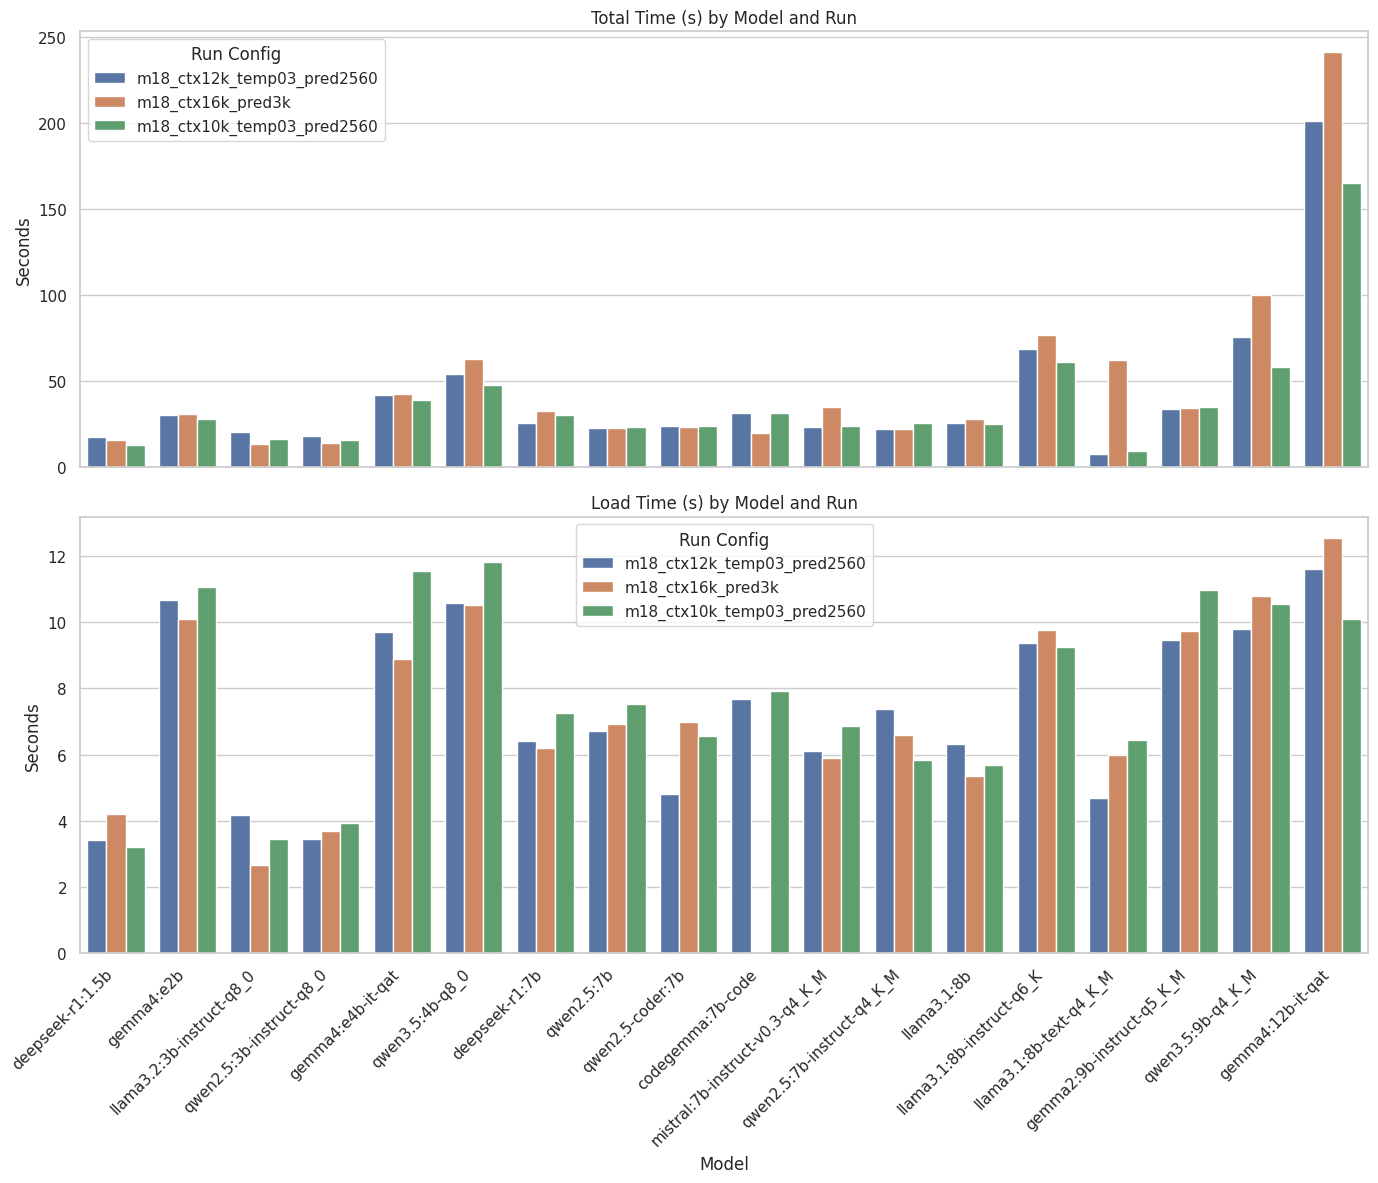

In [13]:
# 1. Total Time (s) and Load Time (s)
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

sns.barplot(ax=axes[0], data=df_all, x="Model", y="Total Time (s)", hue="Run Name")
axes[0].set_title("Total Time (s) by Model and Run")
axes[0].set_ylabel("Seconds")
axes[0].legend(title="Run Config")

sns.barplot(ax=axes[1], data=df_all, x="Model", y="Load Time (s)", hue="Run Name")
axes[1].set_title("Load Time (s) by Model and Run")
axes[1].set_ylabel("Seconds")
axes[1].set_xlabel("Model")
axes[1].legend(title="Run Config")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

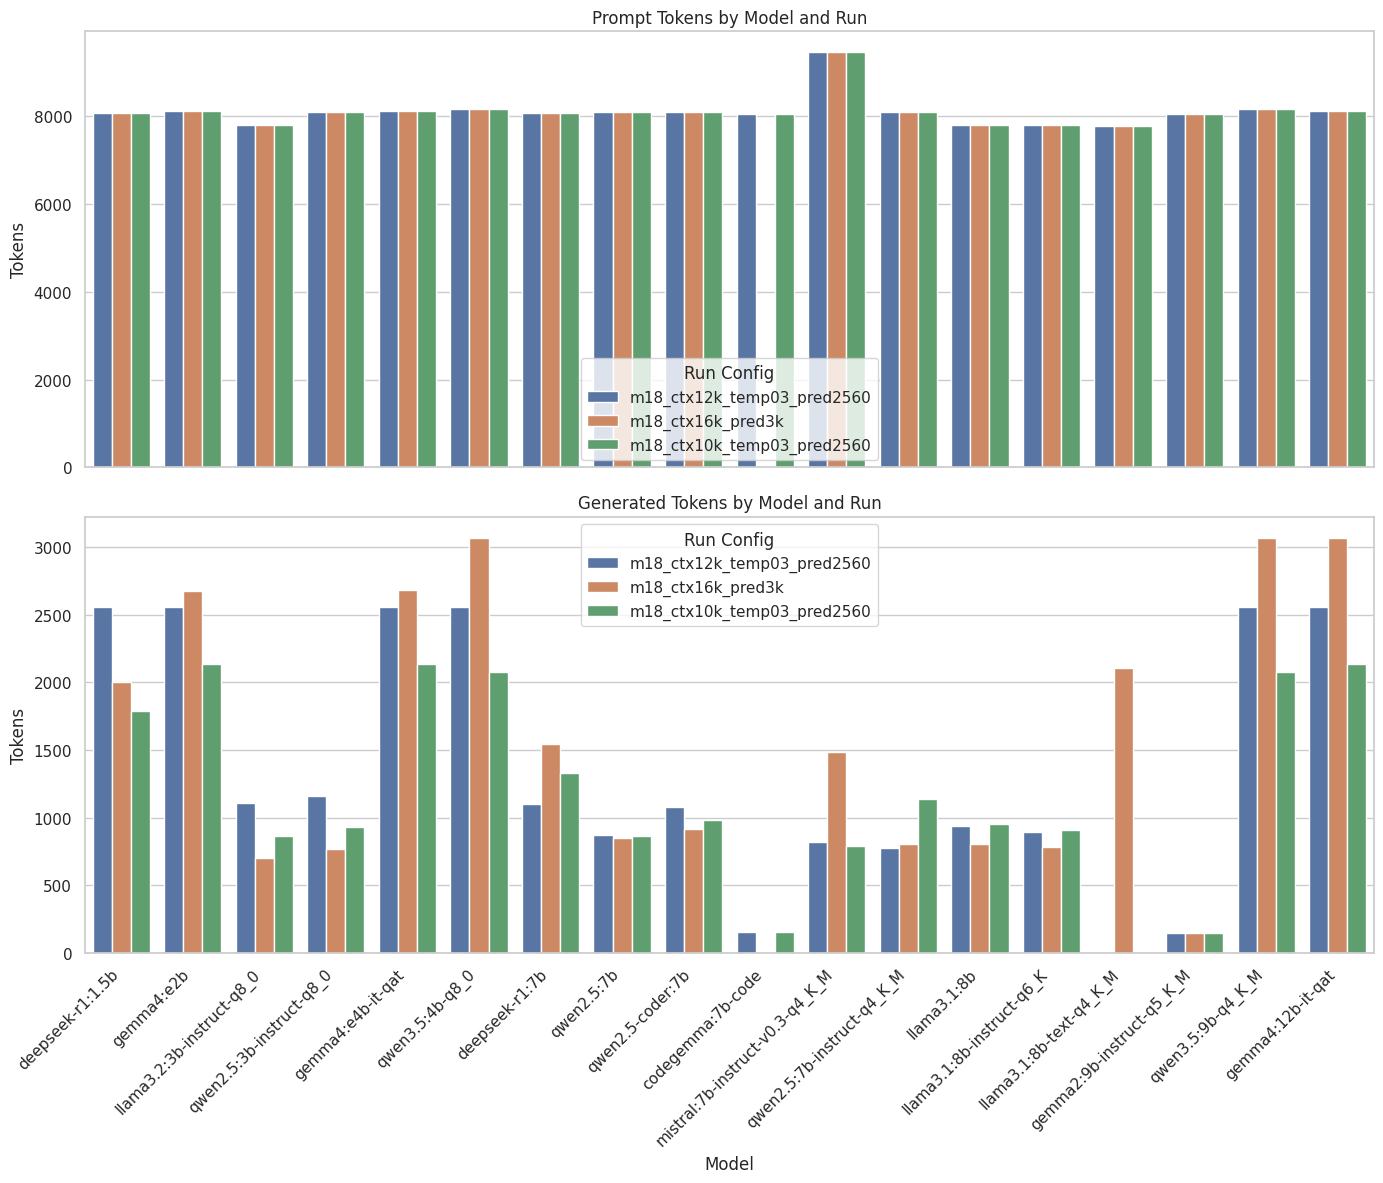

In [14]:
# 2. Prompt Tokens and Gen Tokens
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

sns.barplot(ax=axes[0], data=df_all, x="Model", y="Prompt Tokens", hue="Run Name")
axes[0].set_title("Prompt Tokens by Model and Run")
axes[0].set_ylabel("Tokens")
axes[0].legend(title="Run Config")

sns.barplot(ax=axes[1], data=df_all, x="Model", y="Gen Tokens", hue="Run Name")
axes[1].set_title("Generated Tokens by Model and Run")
axes[1].set_ylabel("Tokens")
axes[1].set_xlabel("Model")
axes[1].legend(title="Run Config")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

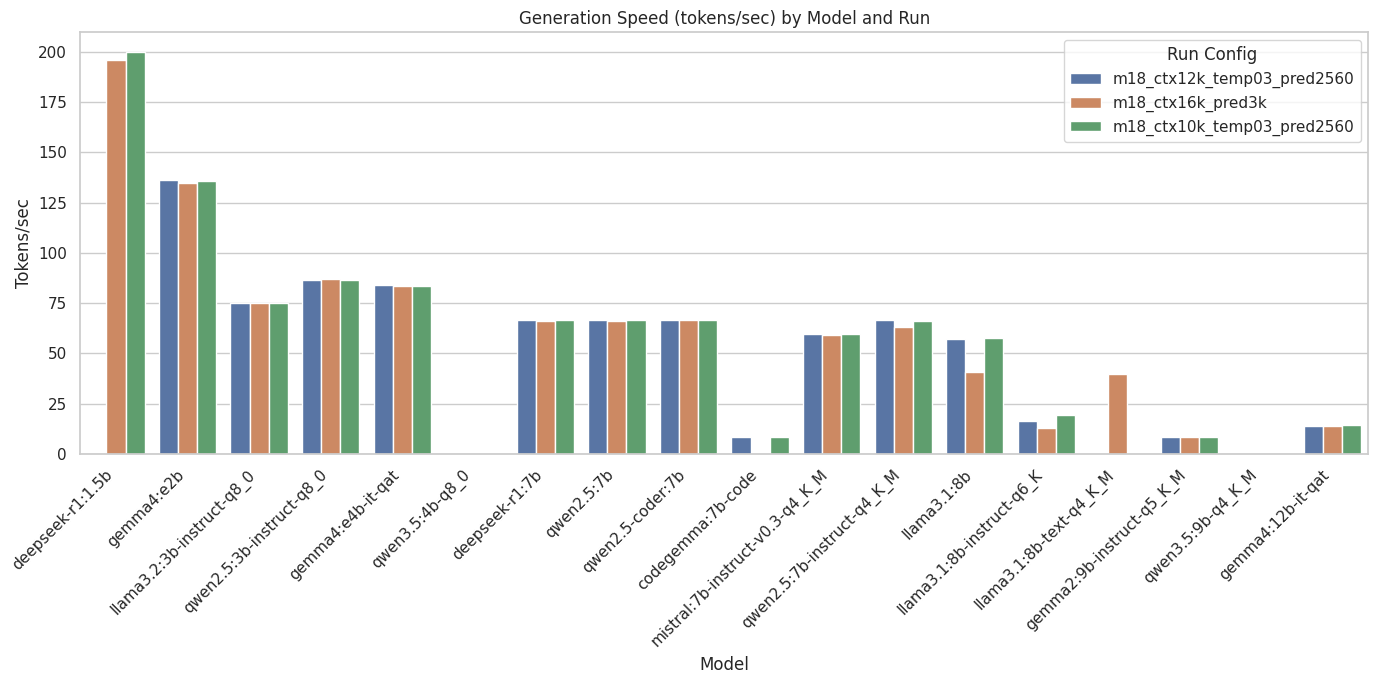

In [15]:
# 3. Gen Speed (t/s)
plt.figure(figsize=(14, 7))
sns.barplot(data=df_all, x="Model", y="Gen Speed (t/s)", hue="Run Name")
plt.title("Generation Speed (tokens/sec) by Model and Run")
plt.ylabel("Tokens/sec")
plt.xlabel("Model")
plt.legend(title="Run Config")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

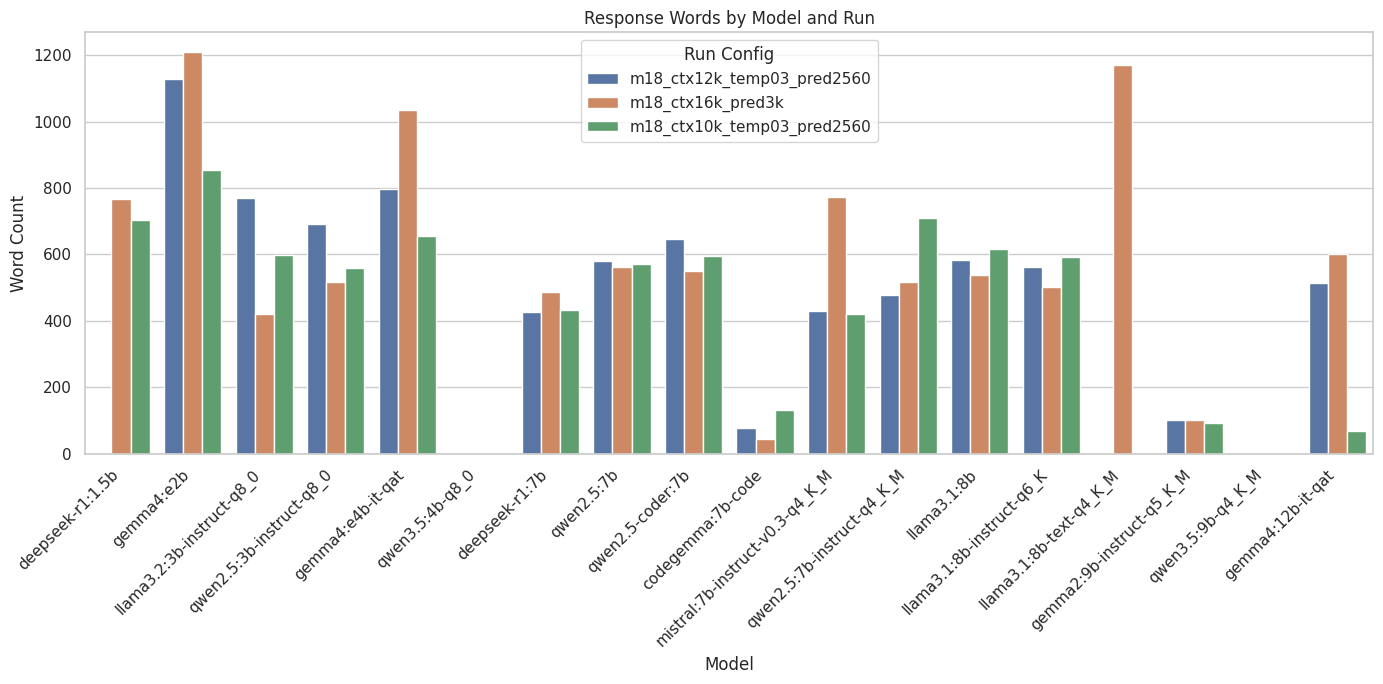

In [16]:
# 4. Response Words
plt.figure(figsize=(14, 7))
sns.barplot(data=df_all, x="Model", y="Response Words", hue="Run Name")
plt.title("Response Words by Model and Run")
plt.ylabel("Word Count")
plt.xlabel("Model")
plt.legend(title="Run Config")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()